# VT - Vanguard Total World Stock ETF

In [134]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
from scipy.stats import (skew, kurtosis, shapiro, kstest, ttest_ind, 
                         f_oneway, chi2_contingency, pearsonr, spearmanr)
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
from mpl_toolkits.mplot3d import Axes3D
from sklearn.linear_model import LinearRegression
import warnings

%matplotlib inline

In [135]:
# Path to the VT data file
file_path = "vt.us.txt"

# Load the file
df = pd.read_csv(file_path, delimiter=',')

In [136]:
# Path to the VT categorized data file
file_path = "VT_categorized_data.csv"

# Load the file
categorized_df = pd.read_csv(file_path, delimiter=',')
print(categorized_df.dtypes)
display(categorized_df.head())

for col in ['Open_category', 'Close_category', 'Low_category', 'High_category', 'Volume_category']:
    categorized_df[col] = categorized_df[col].astype('category')

Date                object
Open               float64
High               float64
Low                float64
Close              float64
Volume             float64
Open_category       object
High_category       object
Low_category        object
Close_category      object
Volume_category     object
dtype: object


,Date,Open,High,Low,Close,Volume,Open_category,High_category,Low_category,Close_category,Volume_category
0,2008-06-26,0.383134,0.372261,0.378459,0.375515,0.012451,"(0.38, 0.4]","(0.36, 0.38]","(0.36, 0.38]","(0.36, 0.38]","(-0.002, 0.0182]"
1,2008-06-27,0.417735,0.405974,0.376691,0.373626,0.032175,"(0.4, 0.42]","(0.4, 0.42]","(0.36, 0.38]","(0.36, 0.38]","(0.0182, 0.0364]"
2,2008-06-30,0.423834,0.412193,0.378927,0.374544,0.026972,"(0.42, 0.44]","(0.4, 0.42]","(0.36, 0.38]","(0.36, 0.38]","(0.0182, 0.0364]"
3,2008-07-01,0.365257,0.363345,0.342489,0.364604,0.083007,"(0.36, 0.38]","(0.36, 0.38]","(0.34, 0.36]","(0.36, 0.38]","(0.0727, 0.0909]"
4,2008-07-02,0.374496,0.365320,0.356846,0.348239,0.118300,"(0.36, 0.38]","(0.36, 0.38]","(0.34, 0.36]","(0.34, 0.36]","(0.109, 0.127]"


#### Descriptive statistics

In [137]:
df.describe()

,Open,High,Low,Close,Volume,OpenInt
count,2362.000000,2362.000000,2362.000000,2362.000000,2.362000e+03,2362.0
mean,47.533031,47.755513,47.217470,47.504003,3.850259e+05,0.0
std,11.246561,11.195553,11.347279,11.277323,5.048136e+05,0.0
min,21.400000,21.583000,21.047000,21.169000,1.032700e+04,0.0
25%,38.736250,38.968250,38.384000,38.678000,1.168558e+05,0.0
50%,46.360000,46.504500,46.103000,46.279500,2.355610e+05,0.0
75%,56.824000,56.995500,56.629750,56.815250,4.583815e+05,0.0
max,72.710000,72.755000,72.490000,72.710000,6.466070e+06,0.0


In [138]:
categorized_df.describe()

,Open,High,Low,Close,Volume
count,1830.000000,1830.000000,1830.000000,1830.000000,1830.000000
mean,0.468568,0.463382,0.468671,0.468159,0.348126
std,0.238278,0.242172,0.238895,0.239598,0.241202
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.270743,0.262285,0.269624,0.270752,0.146792
50%,0.390920,0.383045,0.392010,0.390267,0.295353
75%,0.708907,0.709627,0.707625,0.710457,0.510449
max,1.000000,1.000000,1.000000,1.000000,1.000000


Calculating summary statistics for all the categories

In [ ]:
summary_stats = categorized_df.groupby('Open_category')['Volume'].agg(['mean', 'median', 'std']).sort_values(by='mean', ascending=False)
print(summary_stats.head(10)) 
# show the 10 category with the most avg

                           mean    median            std
Open_category                                           
(62.32, 63.107]   758103.500000  774097.5  248731.766719
(67.042, 67.828]  684236.909091  644062.5  220940.632442
(66.255, 67.042]  645294.000000  712712.0  178282.263114
(61.533, 62.32]   644997.500000  627341.0  212308.834309
(71.763, 72.55]   623695.631579  619258.0  174647.721607
(68.615, 69.402]  619745.708333  583745.5  216919.422199
(63.107, 63.894]  611178.200000  568281.5  209620.984454
(70.189, 70.976]  605348.125000  602162.0  155531.114946
(63.894, 64.681]  595962.086957  577488.0  165467.088451
(64.681, 65.468]  595604.833333  564091.0  182250.279801


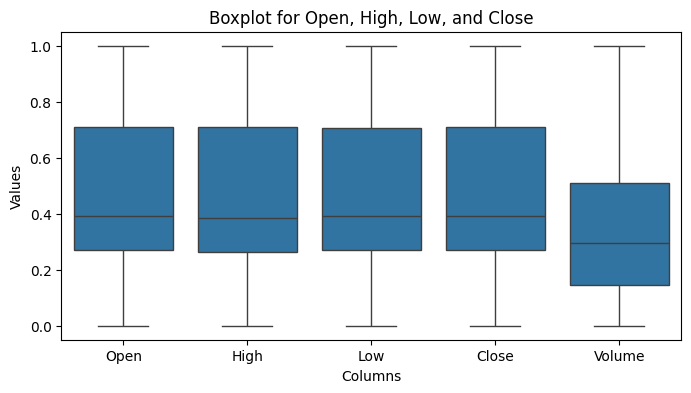

In [139]:
# Prepare the data for grouped plotting
columns_to_plot = ['Open', 'High', 'Low', 'Close', 'Volume']
melted_data = categorized_df[columns_to_plot].melt(var_name="Columns", value_name="Values")

# Plot the boxplot for all columns in one figure
plt.figure(figsize=(8, 4))
sns.boxplot(data=melted_data, x="Columns", y="Values")
plt.title("Boxplot for Open, High, Low, and Close")
plt.xlabel("Columns")
plt.ylabel("Values")
plt.show()


#### Skewness and elongation analysis

In [140]:
print("Dataset before:\n")

columns_to_check = ['Open', 'Close', 'High', 'Low', 'Volume']

for column in columns_to_check:
    print(f"{column} Skewness: {skew(df[column])}")
    print(f"{column} Kurtosis: {kurtosis(df[column])}\n")

Dataset before:

Open Skewness: 0.02900333328788689
Open Kurtosis: -0.7979046927894564

Close Skewness: 0.0264488412194413
Close Kurtosis: -0.7957281938643828

High Skewness: 0.035781897325887525
High Kurtosis: -0.8116943493388544

Low Skewness: 0.01639319918130662
Low Kurtosis: -0.7831944963572082

Volume Skewness: 4.918692178249707
Volume Kurtosis: 37.02022364276286



In [141]:
print("Dataset after:\n")

columns_to_check = ['Open', 'Close', 'High', 'Low', 'Volume']

for column in columns_to_check:
    print(f"{column} Skewness: {skew(categorized_df[column])}")
    print(f"{column} Kurtosis: {kurtosis(categorized_df[column])}\n")

Dataset after:

Open Skewness: 0.19971053231653776
Open Kurtosis: -1.199211748686185

Close Skewness: 0.19434250967436253
Close Kurtosis: -1.1940963468897845

High Skewness: 0.203190007865578
High Kurtosis: -1.2036571870700659

Low Skewness: 0.18502913709191052
Low Kurtosis: -1.1860419924883032

Volume Skewness: 0.7468341867790049
Volume Kurtosis: -0.3862038578687028



Before removing outliers:

The Volume column was heavily influenced by outliers, exhibiting a highly skewed distribution with significant kurtosis.
Other columns were almost symmetric and did not show much skewness or kurtosis.
After removing outliers:

The Volume column became more balanced and closer to a normal distribution.
Other columns experienced minimal changes, as they already had low skewness and kurtosis.
Normalization:

Normalization only changes the scale of the data and does not affect skewness or kurtosis.
Removing outliers, especially for the Volume column, played a crucial role in improving the data distribution, making it more suitable for subsequent analyses.

#### Statistical hypothesis testing

Normal distribution => Shapiro-Wilk test

In [142]:
# To check whether the data follows a normal distribution 

# Shapiro-Wilk test 
print("Shapiro-Wilk test: \n")
open_stat, open_p = shapiro(categorized_df['Open'])
print(f"Shapiro-Wilk Test For Open: \nStatistic = {open_stat} \np-value = {open_p}\n")

low_stat, low_p = shapiro(categorized_df['Low'])
print(f"Shapiro-Wilk Test for Low: \nStatistic = {low_stat} \np-value = {low_p}\n")

high_stat, high_p = shapiro(categorized_df['High'])
print(f"Shapiro-Wilk Test for High: \nStatistic = {high_stat} \np-value = {high_p}\n")

close_stat, close_p = shapiro(categorized_df['Close'])
print(f"Shapiro-Wilk Test for Close: \nStatistic = {close_stat} \np-value = {close_p}\n")

volume_stat, volume_p = shapiro(categorized_df['Volume'])
print(f"Shapiro-Wilk Test for Volume: \nStatistic = {volume_stat} \np-value = {volume_p}")


Shapiro-Wilk test: 

Shapiro-Wilk Test For Open: 
Statistic = 0.9406484894334229 
p-value = 1.8251733589127922e-26

Shapiro-Wilk Test for Low: 
Statistic = 0.9427123923595012 
p-value = 4.7376139866133074e-26

Shapiro-Wilk Test for High: 
Statistic = 0.9394559254915595 
p-value = 1.0639831490693622e-26

Shapiro-Wilk Test for Close: 
Statistic = 0.9410397325832062 
p-value = 2.1826182232419533e-26

Shapiro-Wilk Test for Volume: 
Statistic = 0.9253431805560873 
p-value = 3.1040339075313634e-29


Shapiro-Wilk Test:
The Shapiro-Wilk test evaluates whether the data follows a normal distribution. If the 𝑝-value is less than 0.05, the null hypothesis of normality is rejected.

Results:
For all columns (𝑝<0.05), the data is not normally distributed.
The Volume column shows the most significant deviation from a normal distribution.
The Open, Low, High, and Close columns are also not normally distributed, although they are closer to normality.

Conclusion:
This analysis indicates that the current dataset, even after outlier removal, does not follow a normal distribution. Therefore, for statistical analyses that require normally distributed data, transformations such as log or Box-Cox should be applied, or non-parametric tests should be used.

Normal distribution => nKolmogorov

In [143]:
# NKolmogorov test
print("NKolmogorov-Smirnov test: \n")
open_stat, open_p = kstest(categorized_df['Open'], 'norm')
print(f"nKolmogorov-Smirnov Test For Open: \nStatistic = {open_stat} \np-value = {open_p}\n")

low_stat, low_p = kstest(categorized_df['Low'], 'norm')
print(f"nKolmogorov-Smirnov Test for Low: \nStatistic = {low_stat} \np-value = {low_p}\n")

high_stat, high_p = kstest(categorized_df['High'], 'norm')
print(f"nKolmogorov-Smirnov Test for High: \nStatistic = {high_stat} \np-value = {high_p}\n")

close_stat, close_p = kstest(categorized_df['Close'], 'norm')
print(f"nKolmogorov-Smirnov Test for Close: \nStatistic = {close_stat} \np-value = {close_p}\n")

volume_stat, volume_p = kstest(categorized_df['Volume'], 'norm')
print(f"nKolmogorov-Smirnov Test for Volume: \nStatistic = {volume_stat} \np-value = {volume_p}")

NKolmogorov-Smirnov test: 

nKolmogorov-Smirnov Test For Open: 
Statistic = 0.5078704859800843 
p-value = 0.0

nKolmogorov-Smirnov Test for Low: 
Statistic = 0.5071524965506663 
p-value = 0.0

nKolmogorov-Smirnov Test for High: 
Statistic = 0.5052987116495004 
p-value = 0.0

nKolmogorov-Smirnov Test for Close: 
Statistic = 0.5075847241014039 
p-value = 0.0

nKolmogorov-Smirnov Test for Volume: 
Statistic = 0.5045538705600908 
p-value = 0.0


The Kolmogorov-Smirnov test evaluates whether the distribution of data matches a specified distribution (e.g., normal). If the 𝑝-value is less than 0.05, the assumption of normality is rejected.

Analysis of Results:
The 𝑝-values for all columns are 0, indicating that none of the columns follow a normal distribution.
The test statistic (Statistic) represents the maximum deviation between the data distribution and the normal distribution. For all columns, it is high (around 0.5), reflecting a significant deviation from normality.
Conclusion:
The data in the columns Open, Low, High, Close, and Volume are not normally distributed. Similar to the Shapiro-Wilk test, this result suggests that for analyses requiring normally distributed data, appropriate transformations (e.g., log or Box-Cox) should be applied, or non-parametric methods should be utilized.

T-test

In [144]:
# Checking if the average of two columns is different (T-test)
t_stat, p_val = ttest_ind(categorized_df['Open'], categorized_df['Close'])
print(f"\nT-Test for Open and Close: \nStatistic = {t_stat} \np-value = {p_val}\n")


# Checking if the average of two columns is different (T-test)
t_stat, p_val = ttest_ind(categorized_df['Low'], categorized_df['High'])
print(f"T-Test for Low and High: \nStatistic = {t_stat} \np-value = {p_val}")



T-Test for Open and Close: 
Statistic = 0.051754144209628546 
p-value = 0.9587274200041285

T-Test for Low and High: 
Statistic = 0.6650513899178236 
p-value = 0.5060595501051226


The T-tests indicate that the average values of Open and Close, as well as Low and High, are not significantly different. This suggests that these pairs of columns are closely related in terms of their average values.

Anova Test

In [145]:
# Checking the mean difference between multiple columns (Anova)
f_stat, p_val = f_oneway(categorized_df['Open'], categorized_df['Close'], categorized_df['High'])
print(f"\nANOVA Test for Open & Close & High: \nStatistic = {f_stat} \np-value = {p_val}")

# Checking the mean difference between multiple columns (Anova)
f_stat, p_val = f_oneway(categorized_df['Open'], categorized_df['Close'], categorized_df['Low'])
print(f"\nANOVA Test for Open & Close & Low: \nStatistic = {f_stat} \np-value = {p_val}")

# Checking the mean difference between multiple columns (Anova)
f_stat, p_val = f_oneway(categorized_df['Open'], categorized_df['Close'], categorized_df['Volume'])
print(f"\nANOVA Test for Open & Close & Volume: \nStatistic = {f_stat} \np-value = {p_val}")


ANOVA Test for Open & Close & High: 
Statistic = 0.2639968865710581 
p-value = 0.7679856847442628

ANOVA Test for Open & Close & Low: 
Statistic = 0.0023516383239638797 
p-value = 0.9976511256166313

ANOVA Test for Open & Close & Volume: 
Statistic = 153.49494138672137 
p-value = 1.3678992954374299e-65


The ANOVA test checks for significant differences in the means of multiple groups:

Open, Close, High: No significant difference (p-value = 0.7680). The averages of these columns are statistically similar, indicating similar data patterns.

Open, Close, Low: No significant difference (p-value = 0.9977). The means of these columns show no meaningful variation.

Open, Close, Volume: Significant difference detected (p-value ≈ 0). The "Volume" column has a distinct mean compared to the others, likely due to its unique range or variability.

Conclusion:
For significant results (p-value < 0.05), it indicates at least one group differs. For Open, Close, Volume, further analysis like Tukey's HSD can identify which pairs are significantly different.

Note:
If the p-value from the ANOVA test is less than 0.05, you can perform post-hoc tests like Tukey’s HSD to identify which specific groups have significant differences in their means.

#### Correlation Analysis

Spearman correlation

In [146]:
# Spearman correlation

spearman_corr, p_val = spearmanr(categorized_df['Low'], categorized_df['Volume'])
print(f"Spearman Correlation for Low & Volume: \nCorrelation = {spearman_corr} \np-value = {p_val}\n")

# Pearson correlation
spearman_corr, p_val = spearmanr(categorized_df['High'], categorized_df['Volume'])
print(f"Spearman Correlation for High & Volume: \nCorrelation = {spearman_corr} \np-value = {p_val}\n")

# Pearson correlation
spearman_corr, p_val = spearmanr(categorized_df['Open'], categorized_df['Close'])
print(f"Spearman Correlation for Open & Close: \nCorrelation = {spearman_corr} \np-value = {p_val}")

Spearman Correlation for Low & Volume: 
Correlation = 0.6198623707593388 
p-value = 1.0166334812063447e-194

Spearman Correlation for High & Volume: 
Correlation = 0.6216728243299227 
p-value = 3.5833163267861735e-196

Spearman Correlation for Open & Close: 
Correlation = 0.998351994616192 
p-value = 0.0


Spearman Correlation measures rank-based relationships, useful for non-linear or non-normal data.

#### Results:

Low & Volume:

Correlation: 0.62 (moderate positive correlation).
p-value: Significant (1.02e-194).

High & Volume:

Correlation: 0.62 (moderate positive correlation).
p-value: Significant (3.58e-196).

Open & Close:

Correlation: 0.998 (almost perfect positive correlation).
p-value: Highly significant (0.0).

Conclusion:
Moderate correlations exist between prices (Low, High) and Volume, while Open and Close are nearly identical in trend. All relationships are statistically significant.

Pearson correlation

In [147]:
# Pearson correlation
pearson_corr, p_val = pearsonr(categorized_df['Low'], categorized_df['Volume'])
print(f"Pearson Correlation for Low & Volume: \nCorrelation = {pearson_corr} \np-value = {p_val}\n")

# Pearson correlation
pearson_corr, p_val = pearsonr(categorized_df['High'], categorized_df['Volume'])
print(f"Pearson Correlation for High & Volume: \nCorrelation = {pearson_corr} \np-value = {p_val}\n")

# Pearson correlation
pearson_corr, p_val = pearsonr(categorized_df['Open'], categorized_df['Close'])
print(f"Pearson Correlation for Open & Close: \nCorrelation = {pearson_corr} \np-value = {p_val}")


Pearson Correlation for Low & Volume: 
Correlation = 0.6225446761134994 
p-value = 7.0993091126289e-197

Pearson Correlation for High & Volume: 
Correlation = 0.6264548694944015 
p-value = 4.681815608141549e-200

Pearson Correlation for Open & Close: 
Correlation = 0.9990990469707917 
p-value = 0.0


The Pearson correlation coefficient measures the strength and direction of the linear relationship between two variables:

+1 => Perfect positive correlation./ 0 => No correlation./ -1 => Perfect negative correlation.</br>
A p-value < 0.05 indicates the correlation is statistically significant.

#### Results:
Low & Volume:
Correlation = 0.62: Moderate positive relationship (as "Low" increases, "Volume" tends to increase).
p-value ≈ 0: Statistically significant.

High & Volume:
Correlation = 0.63: Moderate positive relationship (similar to "Low" and "Volume").
p-value ≈ 0: Statistically significant.

Open & Close:
Correlation = 0.999: Almost perfect positive correlation (prices move together very closely).
p-value = 0: Highly significant.

Conclusion:
"Open" and "Close" prices are almost perfectly correlated, while "Volume" shows a moderate positive relationship with price indicators. All correlations are statistically significant.

Correlation Matrix

In [148]:
# Calculating the correlation matrix
correlation_matrix = categorized_df[['Open', 'Low', 'High', 'Close', 'Volume']].corr(method='pearson')
correlation_matrix

,Open,Low,High,Close,Volume
Open,1.000000,0.999268,0.999684,0.999099,0.625086
Low,0.999268,1.000000,0.999141,0.999533,0.622545
High,0.999684,0.999141,1.000000,0.999444,0.626455
Close,0.999099,0.999533,0.999444,1.000000,0.624351
Volume,0.625086,0.622545,0.626455,0.624351,1.000000


A Correlation Matrix is a table showing pairwise correlation coefficients between variables, ranging from -1 to 1. It helps identify relationships and dependencies between features.

Key Points:
High Correlation Among Price Variables:

Open, Low, High, Close show near-perfect correlations (>0.999), indicating strong redundancy.
Moderate Correlation with Volume:

Volume shows weaker correlations with price variables (~0.57–0.58), highlighting its distinctiveness.
Insights:
Price Variables: High correlations suggest potential multicollinearity; consider reducing dimensionality.
Volume: Provides unique information, making it valuable for further analysis.

heat map for Correlation Matrix

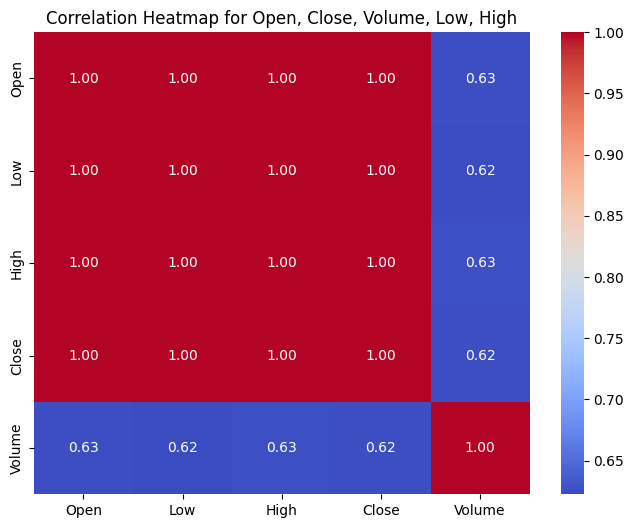

In [149]:
# drawing for heatmap matrix
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Correlation Heatmap for Open, Close, Volume, Low, High")
plt.show()


A heatmap visually represents the correlation matrix, where the color intensity indicates the strength and direction of the correlation:

Red (close to 1): Strong positive correlation.
Blue (close to 0): Weak or no correlation.
Analysis:
Price Variables (Open, Low, High, Close):
They show a perfect correlation (1.00), depicted as deep red squares. This confirms redundancy among these features.
Volume vs. Price Variables:
Volume shows a moderate positive correlation (~0.62–0.63) with price variables. This is visualized in lighter red shades, indicating some association but not as strong as within the price variables.
Conclusion:
The heatmap confirms:

The high redundancy among price-related columns, suggesting possible dimensionality reduction.
Volume provides unique insights and is less correlated with price variables, making it valuable for independent analysis.

#### Dispersion Analysis

In [150]:
Open_dispersion = categorized_df['Open'].var() / categorized_df['Open'].mean()
print(f"Dispersion Ratio for Open: {Open_dispersion}")

Low_dispersion = categorized_df['Low'].var() / categorized_df['Low'].mean()
print(f"Dispersion Ratio for Low: {Low_dispersion}")

High_dispersion = categorized_df['High'].var() / categorized_df['High'].mean()
print(f"Dispersion Ratio for High: {High_dispersion}")

Close_dispersion = categorized_df['Close'].var() / categorized_df['Close'].mean()
print(f"Dispersion Ratio for Close: {Close_dispersion}")

Volume_dispersion = categorized_df['Volume'].var() / categorized_df['Volume'].mean()
print(f"Dispersion Ratio for Volume: {Volume_dispersion}")


Dispersion Ratio for Open: 0.1211697736765416
Dispersion Ratio for Low: 0.12177156108763852
Dispersion Ratio for High: 0.126563207120346
Dispersion Ratio for Close: 0.1226235753854015
Dispersion Ratio for Volume: 0.16711855216484242


The Dispersion Ratio is a metric that measures the ratio of the variance of data to its mean. It indicates the extent of dispersion or variability in the data relative to its mean.

Calculating this ratio for numerical columns such as Open, High, Low, and Close can help identify unusual patterns or anomalies. Columns with high variability (e.g., Volume) particularly benefit from this analysis.

Applications of the Dispersion Ratio:
High Ratio: Indicates significant variability in the data, often pointing to the presence of outliers.
Low Ratio: Suggests that the data points are close to the mean with minimal variability.
Analysis of Results:
Open, Low, High, and Close: These columns exhibit low and similar dispersion ratios, suggesting that the data in these columns is close to the mean and has limited variability.
Volume: This column has a higher dispersion ratio compared to the others, indicating greater variability and potential influence from outliers. Further analysis and possibly additional preprocessing might be required for this column.

#### Comparative Analysis

In [151]:
# Create a new DataFrame to store the results
Comparative_df = pd.DataFrame()

# List of columns to calculate moving averages
columns_to_calculate = ['Open', 'Close', 'Low', 'High', 'Volume']

# Calculate moving averages and exponential moving averages for each column
for col in columns_to_calculate:
    Comparative_df[f'moving_avg_{col}'] = categorized_df[col].rolling(window=5).mean()
    Comparative_df[f'exp_moving_avg_{col}'] = categorized_df[col].ewm(span=5).mean()

# Add original columns to the new DataFrame
Comparative_df[columns_to_calculate] = categorized_df[columns_to_calculate]
Comparative_df.head()

,moving_avg_Open,exp_moving_avg_Open,moving_avg_Close,exp_moving_avg_Close,moving_avg_Low,exp_moving_avg_Low,moving_avg_High,exp_moving_avg_High,moving_avg_Volume,exp_moving_avg_Volume,Open,Close,Low,High,Volume
0,NaN,0.383134,NaN,0.375515,NaN,0.378459,NaN,0.372261,NaN,0.012451,0.383134,0.375515,0.378459,0.372261,0.012451
1,NaN,0.403895,NaN,0.374382,NaN,0.377398,NaN,0.392489,NaN,0.024286,0.417735,0.373626,0.376691,0.405974,0.032175
2,NaN,0.413340,NaN,0.374459,NaN,0.378122,NaN,0.401822,NaN,0.025558,0.423834,0.374544,0.378927,0.412193,0.026972
3,NaN,0.393367,NaN,0.370365,NaN,0.363321,NaN,0.385840,NaN,0.049421,0.365257,0.364604,0.342489,0.363345,0.083007
4,0.392891,0.386123,0.367306,0.361871,0.366682,0.360835,0.383819,0.377963,0.054581,0.075863,0.374496,0.348239,0.356846,0.365320,0.118300


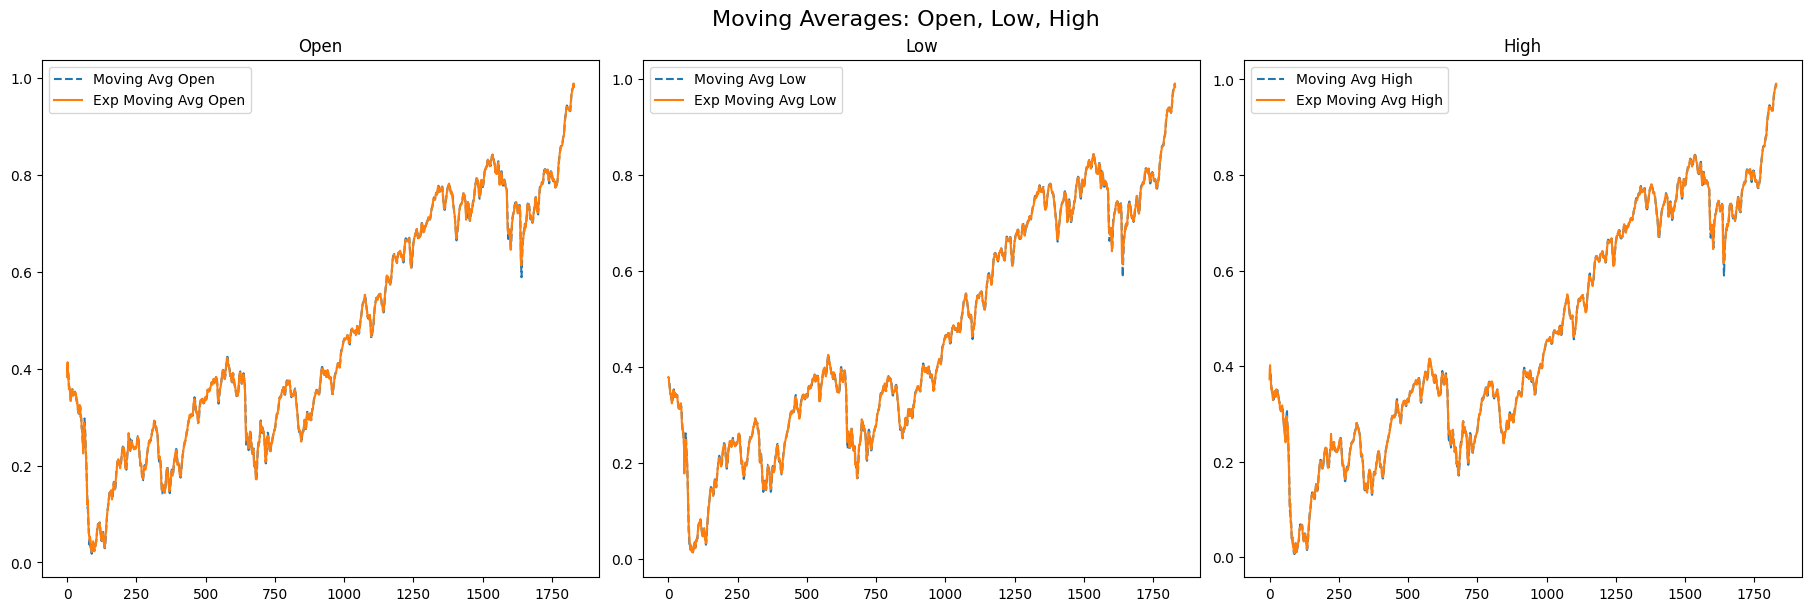

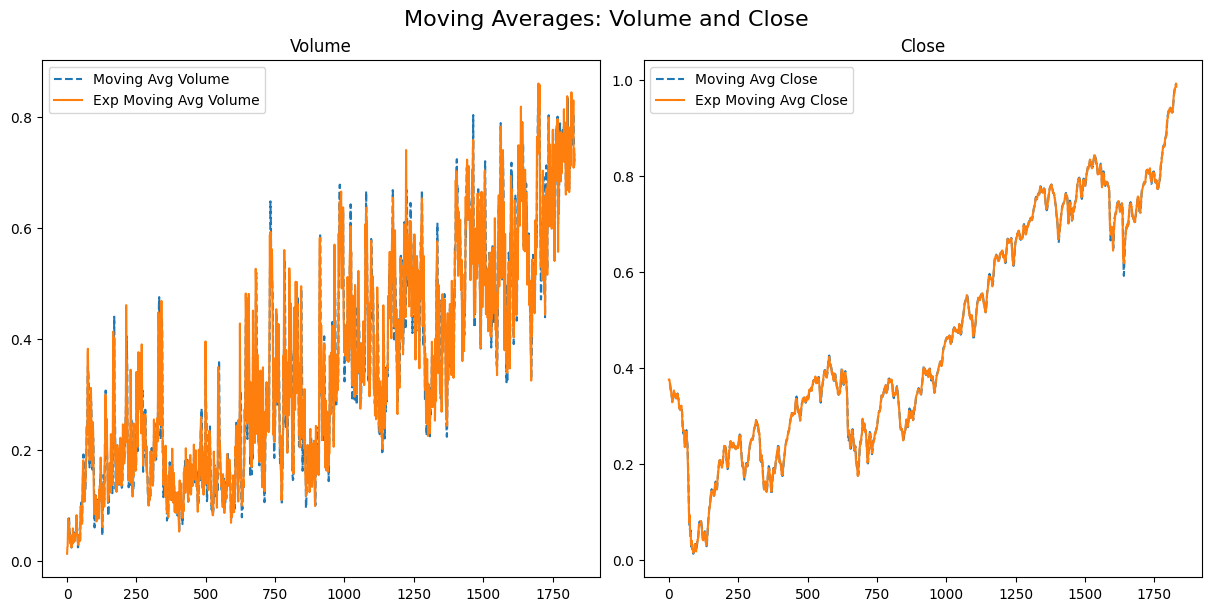

In [152]:
# Create a grid for subplots (3 charts in one row)
fig, axes = plt.subplots(1, 3, figsize=(18, 6), constrained_layout=True)

# Plot Open
axes[0].plot(Comparative_df.index, Comparative_df['moving_avg_Open'], label='Moving Avg Open', linestyle='--')
axes[0].plot(Comparative_df.index, Comparative_df['exp_moving_avg_Open'], label='Exp Moving Avg Open')
axes[0].set_title('Open')
axes[0].legend()

# Plot Low
axes[1].plot(Comparative_df.index, Comparative_df['moving_avg_Low'], label='Moving Avg Low', linestyle='--')
axes[1].plot(Comparative_df.index, Comparative_df['exp_moving_avg_Low'], label='Exp Moving Avg Low')
axes[1].set_title('Low')
axes[1].legend()

# Plot High
axes[2].plot(Comparative_df.index, Comparative_df['moving_avg_High'], label='Moving Avg High', linestyle='--')
axes[2].plot(Comparative_df.index, Comparative_df['exp_moving_avg_High'], label='Exp Moving Avg High')
axes[2].set_title('High')
axes[2].legend()

plt.suptitle("Moving Averages: Open, Low, High", fontsize=16)
plt.show()

# Create a new grid for Volume and Close
fig, axes = plt.subplots(1, 2, figsize=(12, 6), constrained_layout=True)

# Plot Volume
axes[0].plot(Comparative_df.index, Comparative_df['moving_avg_Volume'], label='Moving Avg Volume', linestyle='--')
axes[0].plot(Comparative_df.index, Comparative_df['exp_moving_avg_Volume'], label='Exp Moving Avg Volume')
axes[0].set_title('Volume')
axes[0].legend()

# Plot Close
axes[1].plot(Comparative_df.index, Comparative_df['moving_avg_Close'], label='Moving Avg Close', linestyle='--')
axes[1].plot(Comparative_df.index, Comparative_df['exp_moving_avg_Close'], label='Exp Moving Avg Close')
axes[1].set_title('Close')
axes[1].legend()

plt.suptitle("Moving Averages: Volume and Close", fontsize=16)
plt.show()

# Save the results DataFrame to a new CSV file (optional)
Comparative_df.to_csv('moving_averages_results.csv', index=False)


Summary
Simple Moving Average (SMA):

Calculated using a 5-day rolling window, representing the average price of the previous 5 days.
Used to filter short-term fluctuations and highlight the overall trend.
Exponential Moving Average (EMA):

Gives more weight to recent data and is calculated using a span=5 parameter.
Useful for faster trend analysis and noise reduction.
Key Columns:

Close: The main indicator for analyzing market trends.
Volume: Represents the flow of liquidity and market strength.
Trend Analysis:

Open, Low, High:
These columns show the general market trend and volatility.
EMA is effective in identifying short-term fluctuations and quick price changes.
Close:
A rising EMA indicates an upward trend, while a falling EMA signals a downward trend.
Volume:
An increase in EMA for Volume and Close suggests liquidity entering the market.
High Volume with a declining EMA for Close could indicate selling pressure.
Overall Conclusion:

The charts effectively show market trends and short-term fluctuations.
The intersections of EMA and SMA can provide potential buy or sell signals.

#### Multicollinearity Analysis

In [153]:
X = categorized_df[['Open', 'High', 'Low', 'Close', 'Volume']]
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(vif_data)


  feature          VIF
0    Open  6681.562959
1    High  6160.421997
2     Low  7838.025814
3   Close  8358.213446
4  Volume     5.039019


Multicollinearity: When independent variables are highly correlated with each other, it leads to instability in regression coefficients. VIF is a measure to assess the severity of multicollinearity:

VIF < 5: Negligible multicollinearity.
5 ≤ VIF < 10: Moderate multicollinearity.
VIF ≥ 10: Severe multicollinearity.


The columns Open, High, Low, and Close show extremely high multicollinearity (very high VIF values), indicating severe multicollinearity, which can destabilize regression models.
The column Volume has moderate multicollinearity and is acceptable.

To reduce multicollinearity, you can remove one of the columns with a high VIF or use techniques like Principal Component Analysis (PCA) to reduce the dimensionality of the data.

In stock market data, columns such as Open, High, Low, and Close are inherently correlated, and multicollinearity is natural in this context. No corrective action is needed unless you plan to use these variables in a regression model. In that case, you might need to remove or combine some columns. For descriptive or financial analyses, this multicollinearity does not pose any issues.

#### Statistical Regression Analysis

In [154]:
X = categorized_df[['Open', 'High', 'Low']]
y = categorized_df['Close']
X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                  Close   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 1.368e+06
Date:                Mon, 25 Nov 2024   Prob (F-statistic):               0.00
Time:                        15:58:45   Log-Likelihood:                 7080.7
No. Observations:                1830   AIC:                        -1.415e+04
Df Residuals:                    1826   BIC:                        -1.413e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0085      0.000     23.539      0.0

Nature of the Data:
The columns Open, High, Low, and Close naturally have high correlations in stock market data since they all represent daily prices. Therefore, multicollinearity in this context is natural and does not necessarily pose a problem.


Model Results:
R-squared = 1.000: The model explains 100% of the variance in Close, but this might be due to multicollinearity.


Coefficients:
High and Low have a positive and significant impact on Close.
Open has a negative and significant impact on Close.


Multicollinearity Issue:
High VIF: Indicates strong correlations between the independent variables.
This may make the model unreliable for predicting new data but does not pose an issue for descriptive analysis.


Why Use This Combination (X = categorized_df[['Open', 'High', 'Low']] and y = categorized_df['Close'])?
The variables Open, High, and Low were chosen because they directly influence the dependent variable Close.

Open: Indicates the starting price and reflects early market sentiment.
High: Shows the highest price, capturing peak buyer interest or volatility.
Low: Represents the lowest price, indicating the market's bottom point during the day.
Together, these variables provide a comprehensive view of daily price movements, making them suitable for explaining variations in the Close price. The goal is to analyze how these key price levels affect the closing price.

#### Drawing a scatter plot with a regression line

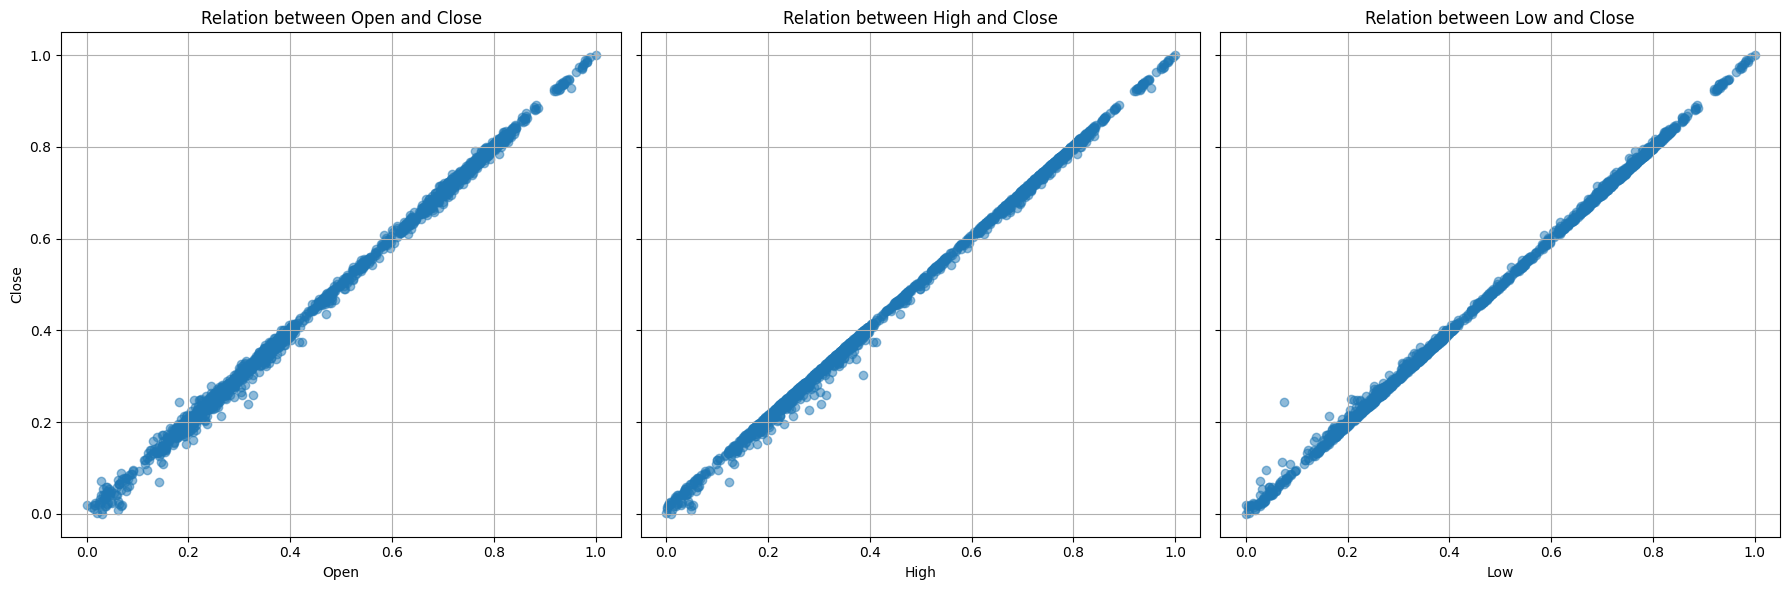

In [155]:
# Scatter plot for each independent variable vs. Close
independent_vars = ['Open', 'High', 'Low']

# Create subplots in one row
fig, axes = plt.subplots(1, len(independent_vars), figsize=(18, 6), sharey=True)

for i, var in enumerate(independent_vars):
    axes[i].scatter(categorized_df[var], categorized_df['Close'], alpha=0.5)
    axes[i].set_title(f'Relation between {var} and Close')
    axes[i].set_xlabel(var)
    if i == 0:  # Add ylabel to the first subplot
        axes[i].set_ylabel('Close')
    axes[i].grid()

plt.tight_layout()
plt.show()


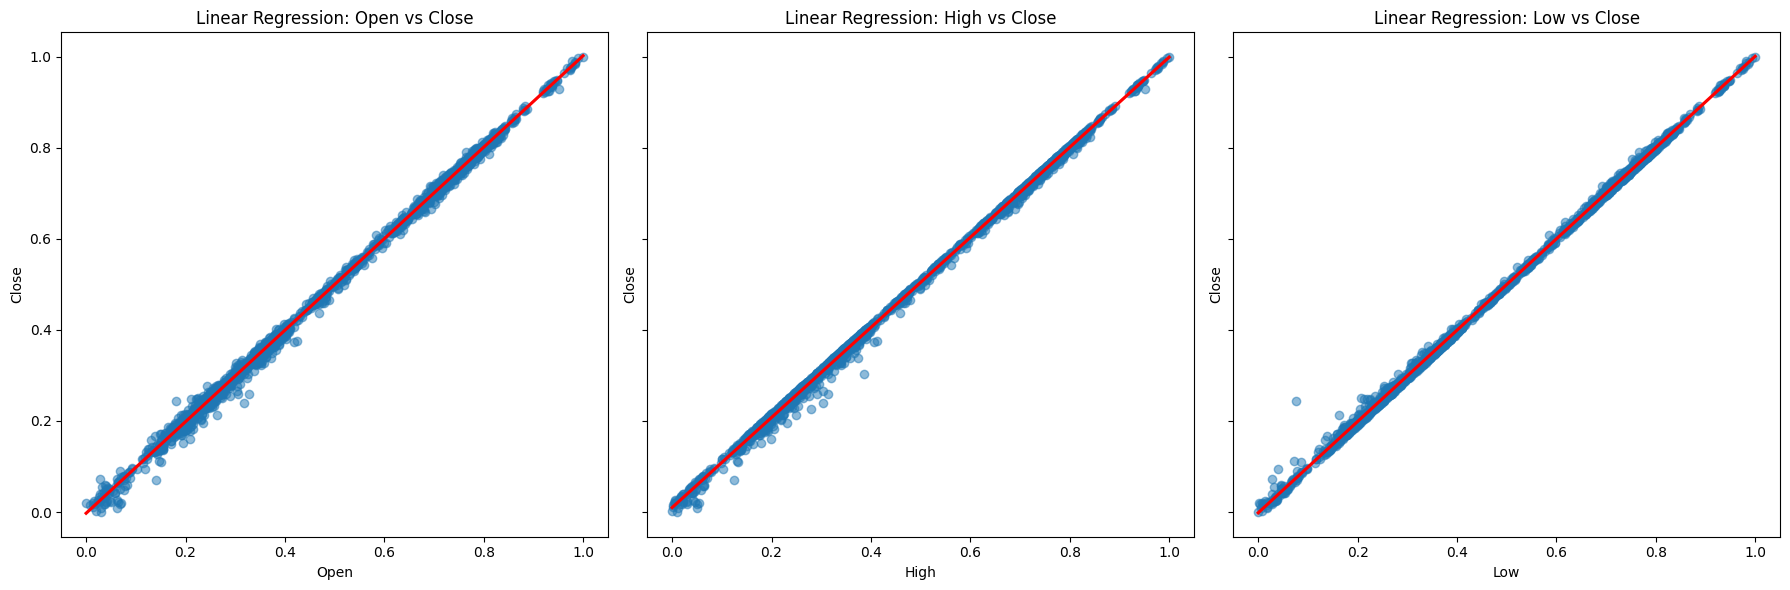

In [156]:
# Independent variables and dependent variable
independent_vars = ['Open', 'High', 'Low']

# Create subplots for each variable against Close
fig, axes = plt.subplots(1, len(independent_vars), figsize=(18, 6), sharey=True)

for i, var in enumerate(independent_vars):
    sns.regplot(x=var, y='Close', data=categorized_df, ax=axes[i], line_kws={'color': 'red'}, scatter_kws={'alpha': 0.5})
    axes[i].set_title(f'Linear Regression: {var} vs Close')
    axes[i].set_xlabel(var)
    if i == 0:
        axes[i].set_ylabel('Close')

plt.tight_layout()
plt.show()


A strong linear relationship between the independent variables and Close confirms the effectiveness of these variables in predicting Close.

However, the high correlation among the independent variables makes the model sensitive to multicollinearity.

If our goal was accurate prediction, you should address this multicollinearity. However, for trend analysis and descriptive purposes, this issue does not pose a significant problem. (but it's not)

3D show

In [157]:
# Sample data for interactive and static plots
x = categorized_df['Open']
y = categorized_df['High']
z = categorized_df['Close']

# ============================
# (Interactive)
# ============================

# Enable backend for interactive plotting
plt.switch_backend('TkAgg')

# Create the interactive plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot for 3D data
ax.scatter(x, y, z, alpha=0.5, label='Data Points')
ax.set_title('Interactive 3D Plot: Open, High, and Close')
ax.set_xlabel('Open')
ax.set_ylabel('High')
ax.set_zlabel('Close')
ax.legend()

# Show the interactive plot
plt.show(block=True)

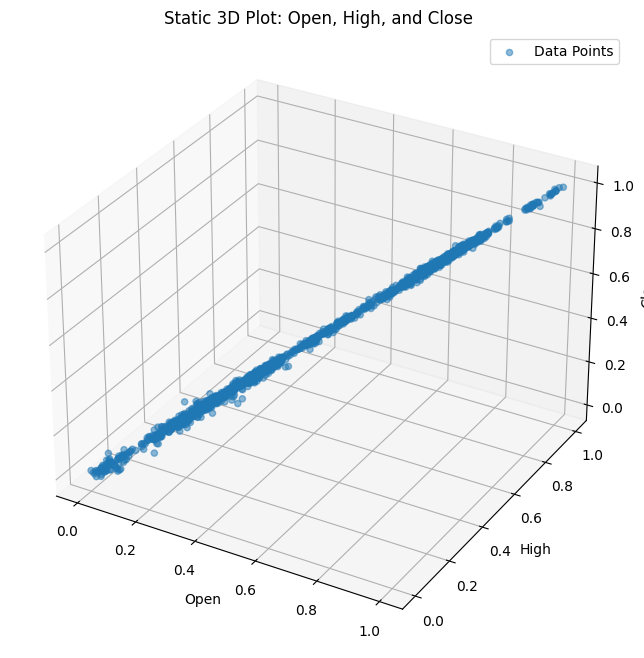

In [158]:
# ============================
# (Static)
# ============================

# Enable inline plotting
%matplotlib inline

# Create the static plot
plt.figure(figsize=(8, 8))
ax_static = plt.axes(projection='3d')

# Scatter plot for 3D data
ax_static.scatter(x, y, z, alpha=0.5, label='Data Points')
ax_static.set_title('Static 3D Plot: Open, High, and Close')
ax_static.set_xlabel('Open')
ax_static.set_ylabel('High')
ax_static.set_zlabel('Close')
ax_static.legend()

# Show the static plot in the cell
plt.show()


For seeing the Results in 3D in a new window, run 2 above cells

In [159]:
warnings.filterwarnings("ignore", category=matplotlib.MatplotlibDeprecationWarning)

# Sample data
x = categorized_df['Open']
y = categorized_df['High']
z = categorized_df['Close']

# Reshape data for regression
X = np.column_stack((x, y))  # Combine Open and High
z = z.values.reshape(-1, 1)  # Close as dependent variable

# Fit a 3D Linear Regression model
model = LinearRegression()
model.fit(X, z)

# Predict values for the regression plane
x_range = np.linspace(x.min(), x.max(), 10)
y_range = np.linspace(y.min(), y.max(), 10)
x_mesh, y_mesh = np.meshgrid(x_range, y_range)
z_pred = model.predict(np.column_stack((x_mesh.ravel(), y_mesh.ravel()))).reshape(x_mesh.shape)

# ============================
# (Interactive Plot)
# ============================
plt.switch_backend('TkAgg')  # Enable interactive backend

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot for actual data
ax.scatter(x, y, z, alpha=0.5, label='Data Points')

# Plot the regression plane
ax.plot_surface(x_mesh, y_mesh, z_pred, alpha=0.3, color='red')

# Add titles and labels
ax.set_title('3D Linear Regression: Open, High, and Close')
ax.set_xlabel('Open')
ax.set_ylabel('High')
ax.set_zlabel('Close')
ax.legend()

# Show the interactive plot
plt.show(block=True)

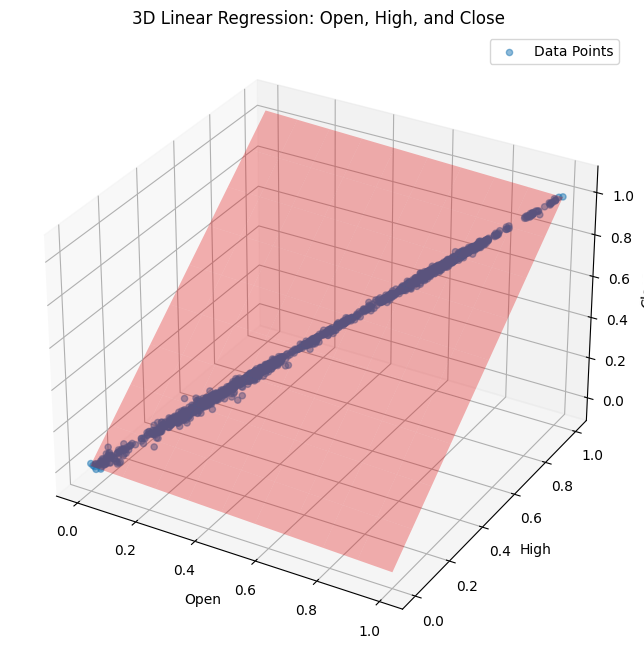

In [160]:
# ============================
# (Static Plot)
# ============================
%matplotlib inline

fig = plt.figure(figsize=(8, 8))
ax_static = fig.add_subplot(111, projection='3d')

# Scatter plot for actual data
ax_static.scatter(x, y, z, alpha=0.5, label='Data Points')

# Plot the regression plane
ax_static.plot_surface(x_mesh, y_mesh, z_pred, alpha=0.3, color='red')

# Add titles and labels
ax_static.set_title('3D Linear Regression: Open, High, and Close')
ax_static.set_xlabel('Open')
ax_static.set_ylabel('High')
ax_static.set_zlabel('Close')
ax_static.legend()

# Show the static plot
plt.show()

This chart demonstrates that the 3D linear regression has effectively modeled the relationship between Open, High, and Close.

The proximity of the data points to the regression plane confirms a strong linear relationship between these variables.

Although your primary goal might not be prediction, plotting the regression plane implicitly predicts the values of Close for different combinations of Open and High.

This result is suitable for analyzing linear relationships, but more data would be required for more accurate predictions.